In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")
import torch
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, max_error, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [4]:
def plot_true_vs_pred_axis(ax, pulse, target, result_dict, color='blue', n_splits=50, title=''):
    df = result_dict[f"{target}, {pulse}"]
    average_pred = df[list(range(n_splits))].mean(axis=1)
    sns.histplot(x=df[target],
        y=average_pred,
        stat='percent',
        bins=30,
        color=color,
        ax=ax)
    ax.axline( (df[target].min(), df[target].min()),
                       (df[target].max(), df[target].max()),
                     linestyle='dashed', color='gray')
    ax.set_title(title)
    ax.annotate("r^2: {:.3f}".format(r2_score(df[target], average_pred)), xy=(0.05, 0.9), xycoords='axes fraction', fontsize=8)

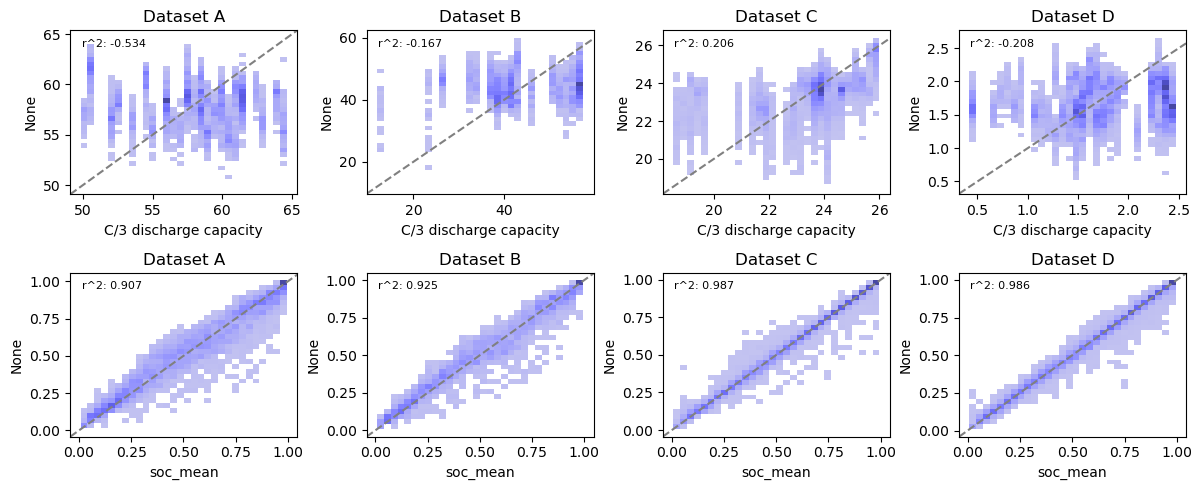

In [5]:


fig, ax = plt.subplots(2,4, figsize=(12, 5))

A = torch.load('../../results/bootstrap_results_A.pth', weights_only=False)
B = torch.load('../../results/bootstrap_results_B.pth', weights_only=False)
C = torch.load('../../results/bootstrap_results_C.pth', weights_only=False)
D = torch.load('../../results/bootstrap_results_D.pth', weights_only=False)

pulses = [
    "Charge_Depleting",
]

targets = [
    "C/3 discharge capacity",
    "soc_mean",
]

data = [A,B,C,D]

for i in range(4):
    for j in range(2):
        plot_true_vs_pred_axis(ax[j,i], pulses[0], targets[j], data[i], n_splits=50, title=f"Dataset {chr(65+i)}")

fig.tight_layout()

In [6]:
hdf = pd.HDFStore('../../data/data_partial_charge_for_ml.h5', mode='r')
keys = hdf.keys()
keys

['/Charge_Depleting',
 '/Charge_Sustaining',
 '/PsRP_1_1C',
 '/PsRP_2_1C',
 '/Rate_Test_1C',
 '/Rate_Test_C/2',
 '/PsRP_2_C/2',
 '/PsRP_1_C/2']

In [7]:
df = hdf.get('/Rate_Test_C/2')

# df
list(df.columns)

['soc_mean',
 'soc_initial',
 'soc_final',
 'voltage_0.0s',
 'voltage_1.0s',
 'voltage_2.0s',
 'voltage_3.0s',
 'voltage_4.0s',
 'voltage_5.0s',
 'voltage_6.0s',
 'voltage_7.0s',
 'voltage_8.0s',
 'voltage_9.0s',
 'voltage_10.0s',
 'voltage_11.0s',
 'voltage_12.0s',
 'voltage_13.0s',
 'voltage_14.0s',
 'voltage_15.0s',
 'voltage_16.0s',
 'voltage_17.0s',
 'voltage_18.0s',
 'voltage_19.0s',
 'voltage_20.0s',
 'voltage_21.0s',
 'voltage_22.0s',
 'voltage_23.0s',
 'voltage_24.0s',
 'voltage_25.0s',
 'voltage_26.0s',
 'voltage_27.0s',
 'voltage_28.0s',
 'voltage_29.0s',
 'voltage_30.0s',
 'voltage_31.0s',
 'voltage_32.0s',
 'voltage_33.0s',
 'voltage_34.0s',
 'voltage_35.0s',
 'voltage_36.0s',
 'voltage_37.0s',
 'voltage_38.0s',
 'voltage_39.0s',
 'voltage_40.0s',
 'voltage_41.0s',
 'voltage_42.0s',
 'voltage_43.0s',
 'voltage_44.0s',
 'voltage_45.0s',
 'voltage_46.0s',
 'voltage_47.0s',
 'voltage_48.0s',
 'voltage_49.0s',
 'voltage_50.0s',
 'voltage_51.0s',
 'voltage_52.0s',
 'voltage_53.

ValueError: Input contains NaN.

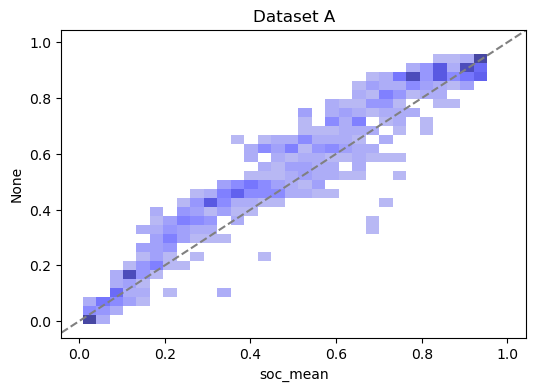

In [8]:
A = torch.load('../../results/fixed/bootstrap_results_A.pth', weights_only=False)


fig, ax = plt.subplots(figsize=(6, 4))
plot_true_vs_pred_axis(ax, "Charge_Depleting", "soc_mean", A, n_splits=50, title=f"Dataset A")


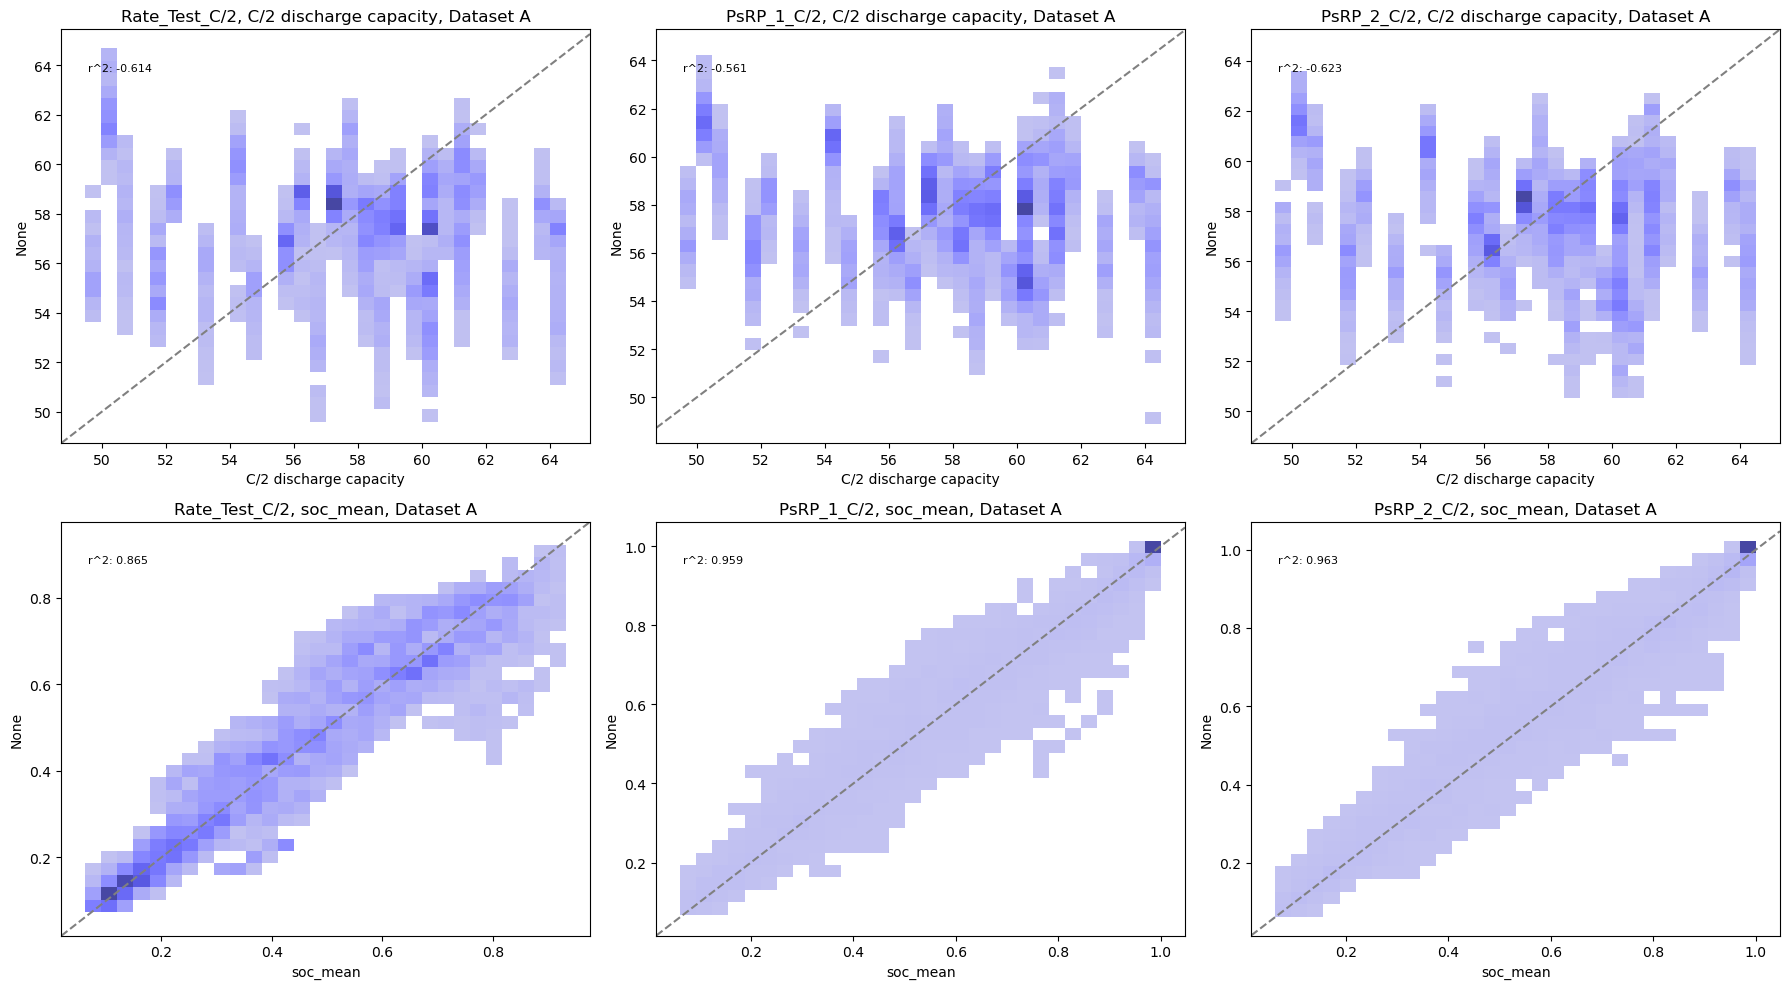

In [ ]:
A = torch.load('../../results/partial_charge/bootstrap_results_A.pth', weights_only=False)

pulses = [
    "Rate_Test_C/2",
    "PsRP_1_C/2",
    "PsRP_2_C/2",
]
targets = [
    "C/2 discharge capacity",
    "soc_mean",
]

fig, ax = plt.subplots(2,3, figsize=(18, 10))
ax = ax.flatten()
for i in range(3):
    plot_true_vs_pred_axis(ax[i], pulses[i], targets[0], A, n_splits=50, title=f"{pulses[i]}, {targets[0]}, Dataset A")
for i in range(3):
    plot_true_vs_pred_axis(ax[i+3], pulses[i], targets[1], A, n_splits=50, title=f"{pulses[i]}, {targets[1]}, Dataset A")
fig.tight_layout()

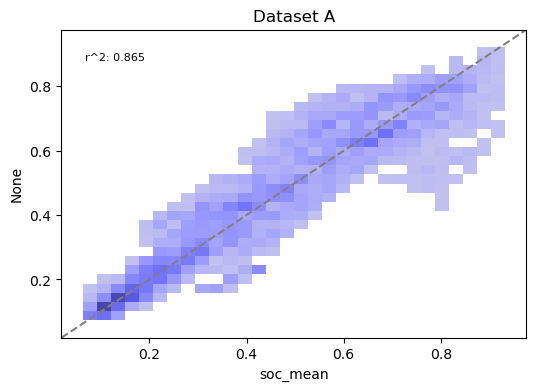

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
A = torch.load('../../results/partial_charge/bootstrap_results_A.pth', weights_only=False)
plot_true_vs_pred_axis(ax, "Rate_Test_C/2", "soc_mean", A, n_splits=50, title=f"Dataset A")

In [4]:
def get_metrics_all_targets(results_dict_list):
    """
    Construct a wide format df for plotting convenience
    """
    metrics = {
                'r2': [],
                'mae': [],
                'mape': [],
                'Target': [],
                'Cell ID': [],
                'Pulse Type': [],
              }
    for results_dict_soc in results_dict_list:
        for key in results_dict_soc:
            if 'features' in key:
                continue
                
            target, pulse = key.split(', ')
            if target == 'Post 1C charge relaxation fit MSE':
                continue
            df = results_dict_soc[key]
            cell_id = df['cell_id'][0][0]

            for run in range(50):
                test_subset = df[df[run].notna()]
                r2 = r2_score(test_subset[target], test_subset[run])
                mae = mean_absolute_error(test_subset[target], test_subset[run])
                mape = mean_absolute_percentage_error(test_subset[target], test_subset[run])         
                metrics[f"r2"].append(r2)
                metrics[f"mae"].append(mae)
                metrics["mape"].append(mape)
                
            metrics['Target'] += [target] * 50
            metrics['Cell ID'] += [cell_id] * 50
            metrics['Pulse Type'] += [pulse] * 50

    return pd.DataFrame(metrics)

Text(0.5, 1.0, 'MAE for SOC prediction')

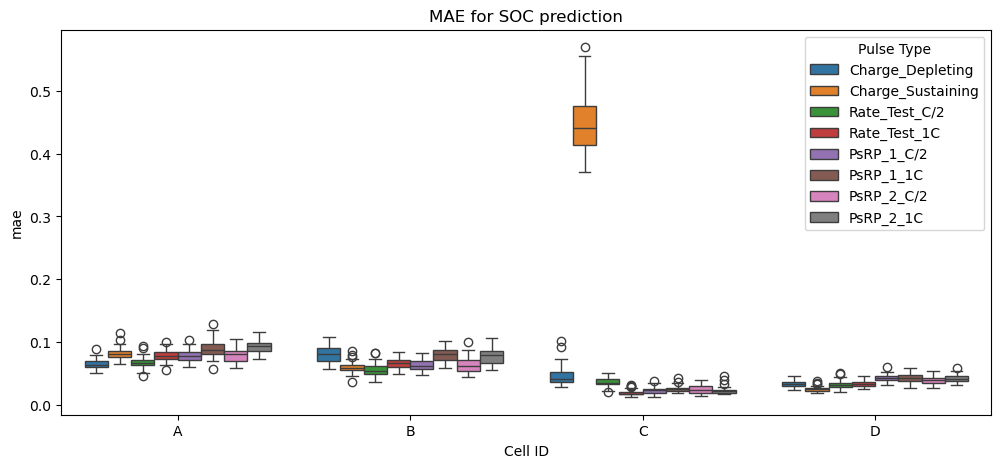

In [ ]:
A_test = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_A.pth', weights_only=False)
B_test = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_B.pth', weights_only=False)
C_test = torch.load('../../results/partial_charge/soc_prediction2/bootstrap_results_C.pth', weights_only=False)
D_test = torch.load('../../results/partial_charge/soc_prediction/bootstrap_results_D.pth', weights_only=False)

metrics = get_metrics_all_targets([A_test, B_test, C_test, D_test])

fig, ax = plt.subplots(figsize=(12, 5))
pulses = [
    "Charge_Depleting",
    "Charge_Sustaining",
    "Rate_Test_C/2",
    "Rate_Test_1C",
    "PsRP_1_C/2",
    "PsRP_1_1C",
    "PsRP_2_C/2",
    "PsRP_2_1C",
]
def t(metrics, target, pulses=None):
    metrics = metrics[metrics['Target'] == target]
    if pulses is not None:
        metrics = metrics[metrics['Pulse Type'].isin(pulses)]
    return metrics
sns.boxplot(t(metrics, "soc_mean", pulses), x='Cell ID', y='mae', hue='Pulse Type', ax=ax)
ax.set_title("MAE for SOC prediction")

Text(0.5, 1.0, 'MAE for C/3 Discharge Capacity prediction')

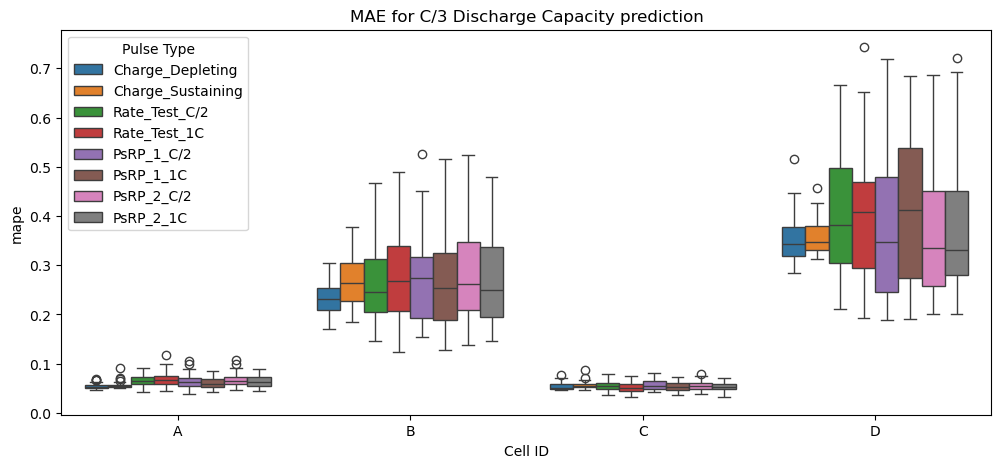

In [62]:
A_discharge = torch.load('../../results/partial_charge/c3_prediction/bootstrap_results_A.pth', weights_only=False)
B_discharge = torch.load('../../results/partial_charge/c3_prediction/bootstrap_results_B.pth', weights_only=False)
C_discharge = torch.load('../../results/partial_charge/c3_prediction/bootstrap_results_C.pth', weights_only=False)
D_discharge = torch.load('../../results/partial_charge/c3_prediction/bootstrap_results_D.pth', weights_only=False)

metrics_discharge = get_metrics_all_targets([A_discharge, B_discharge, C_discharge, D_discharge])
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(t(metrics_discharge, "C/3 discharge capacity", pulses), x='Cell ID', y='mape', hue='Pulse Type', ax=ax)
ax.set_title("MAE for C/3 Discharge Capacity prediction")

In [ ]:
C_test = torch.load('../../results/partial_charge/test/bootstrap_results_C.pth', weights_only=False)
metrics_test = get_metrics_all_targets([C_test])
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(t(metrics_test, "soc_mean", pulses), x='Cell ID', y='mae', hue='Pulse Type', ax=ax)
ax.set_title("MAE for SOC Mean prediction")

In [20]:
df = A_test[list(A_test.keys())[0]]
df

,soc_initial,soc_final,split_type,measurement_id,cell_id,temperature_ambient,C/10 discharge capacity,C/5 discharge capacity,C/3 discharge capacity,C/2 discharge capacity,...,40,41,42,43,44,45,46,47,48,49
0,0.952983,0.949018,testing,0,B_01,30.0,42.00,41.19,40.82,40.37,...,0.895048,0.936778,0.944533,0.964087,0.971159,0.946053,0.969003,0.936374,0.973003,0.934705
1,0.901729,0.897762,testing,0,B_01,30.0,42.00,41.19,40.82,40.37,...,0.882615,0.929906,0.917788,0.938500,0.949159,0.945514,0.963887,0.915748,0.957156,0.942834
2,0.850396,0.846425,testing,0,B_01,30.0,42.00,41.19,40.82,40.37,...,0.911146,0.934967,0.866568,0.934805,0.905144,0.944480,0.933687,0.917145,0.927033,0.945289
3,0.798988,0.794994,testing,0,B_01,30.0,42.00,41.19,40.82,40.37,...,0.801839,0.855289,0.910505,0.856796,0.843481,0.932266,0.908261,0.906011,0.893957,0.917584
4,0.747398,0.743398,testing,0,B_01,30.0,42.00,41.19,40.82,40.37,...,0.772167,0.790138,0.800543,0.808686,0.739948,0.794719,0.772627,0.768227,0.799034,0.698327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19681,0.051111,0.026106,training,27,B_08,30.5,47.69,47.19,46.80,46.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19682,0.072144,0.051825,training,27,B_08,30.5,47.69,47.19,46.80,46.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19683,0.066901,0.044253,training,27,B_08,30.5,47.69,47.19,46.80,46.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19684,0.083678,0.067655,training,27,B_08,30.5,47.69,47.19,46.80,46.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
THRESHOLDS_1C = {
    "A": 3.6e-6,
    "B": 0.0000165,
    "C": 2.5e-06,
}
THRESHOLDS_C_2 = {
    "A": 3.6e-6,
    "B": 0.0000275,
    "C": 5.7e-06,
}

def make_binary(
    df: pd.DataFrame, original_target: str, threshold: float, tag: str = "_outlier"
):
    """
    Binarize a continuous feature by setting all values
    less than a given threshold to 0 and all values above
    the given threshold to 1. Add the binarized feature
    as a new column in df, with the suffix `tag` appended
    to the original name.

    Args:
        df (pd.DataFrame): Set of all data
        original_target (str): Name of variable
                               in df to binarize
        threshold (float): Binarization threshold
        tag (str): Suffix for new binarized feature.

    Return:
        pd.DataFrame
    """
    target = f"{original_target}{tag}"
    df.loc[df[original_target] >= threshold, target] = 1
    df.loc[df[original_target] < threshold, target] = 0
    return df

def filter_cell_type(df: pd.DataFrame, cell_type: str):
    """
    Filter dataframe for cell type A, B, or C.

    Args:
        df (pd.DataFrame):  Dataframe to filter.
                            Expected to have column "cell_id".
        cell_type (str):    Cell type identifier to filter for.

    Returns:
        pd.DataFrame: df filtered for rows where
                      "cell_id" starts with `cell_type`.
    """
    cell_df = df[df["cell_id"].str.startswith(cell_type)]
    return cell_df.reset_index(drop=True)

def load_partial_charge_data(filename: str = "data_partial_charge_for_ml.h5", cell_type: str = None):
    """
    Process data from h5 file into dictionary where keys are
    pulse types and values are dataframes of features/targets.

    Args:
        filename:   Path to h5 file generated by 05_process_data_for_ml.py
        cell_type:  One of {None, "A", "B", "C"}. If provided,
                    filters data only for that cell type.

    Return:
        tests:      Dictionary of feature/target data where each
                    key is a pulse measurement type.
    """

    data = pd.HDFStore(filename)

    charge_depleting = data.get("Charge_Depleting")
    charge_sustaining = data.get("Charge_Sustaining")
    rate_test_C2 = data.get("Rate_Test_C/2")
    rate_test_1C = data.get("Rate_Test_1C")
    psrp_1_C2 = data.get("PsRP_1_C/2")
    psrp_1_1C = data.get("PsRP_1_1C")
    psrp_2_C2 = data.get("PsRP_2_C/2")
    psrp_2_1C = data.get("PsRP_2_1C")

    if cell_type is not None:
        charge_depleting = filter_cell_type(charge_depleting, cell_type)
        charge_sustaining = filter_cell_type(charge_sustaining, cell_type)
        rate_test_C2 = filter_cell_type(rate_test_C2, cell_type)
        rate_test_1C = filter_cell_type(rate_test_1C, cell_type)
        psrp_1_C2 = filter_cell_type(psrp_1_C2, cell_type)
        psrp_1_1C = filter_cell_type(psrp_1_1C, cell_type)
        psrp_2_C2 = filter_cell_type(psrp_2_C2, cell_type)
        psrp_2_1C = filter_cell_type(psrp_2_1C, cell_type)

    # get 1/10 of the randomized samples for use in the model.
    depleting_testing = charge_depleting[charge_depleting['split_type'] == "testing"]
    # depleting_training = charge_depleting.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    depleting_training = charge_depleting[charge_depleting['split_type'] == "training"]
    charge_depleting = pd.concat([depleting_testing, depleting_training])
    charge_depleting.reset_index(drop=True, inplace=True)
    sustaining_testing = charge_sustaining[charge_sustaining['split_type'] == "testing"]
    # sustaining_training = charge_sustaining.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    sustaining_training = charge_sustaining[charge_sustaining['split_type'] == "training"]
    charge_sustaining = pd.concat([sustaining_testing, sustaining_training])
    charge_sustaining.reset_index(drop=True, inplace=True)
    rate_test_C2 = rate_test_C2.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    rate_test_C2.reset_index(drop=True, inplace=True)
    rate_test_1C = rate_test_1C.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    rate_test_1C.reset_index(drop=True, inplace=True)
    psrp_1_C2 = psrp_1_C2.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    psrp_1_C2.reset_index(drop=True, inplace=True)
    psrp_1_1C = psrp_1_1C.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    psrp_1_1C.reset_index(drop=True, inplace=True)
    psrp_2_C2 = psrp_2_C2.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    psrp_2_C2.reset_index(drop=True, inplace=True)
    psrp_2_1C = psrp_2_1C.groupby(by='measurement_id').sample(frac=0.1, random_state=42)
    psrp_2_1C.reset_index(drop=True, inplace=True)

    print(f"charge depleting size: {charge_depleting.shape}")
    print(f"charge sustaining size: {charge_sustaining.shape}")
    print(f"rate test C/2 size: {rate_test_C2.shape}")
    print(f"rate test 1C size: {rate_test_1C.shape}")
    print(f"PsRP 1 C/2 size: {psrp_1_C2.shape}")
    print(f"PsRP 1 1C size: {psrp_1_1C.shape}")
    print(f"PsRP 2 C/2 size: {psrp_2_C2.shape}")
    print(f"PsRP 2 1C size: {psrp_2_1C.shape}")
    #does this sample 10% of measurement ids? or the intended 10% of random samples

    tests = {
        "Charge_Depleting": charge_depleting,
        "Charge_Sustaining": charge_sustaining,
        "Rate_Test_C/2": rate_test_C2,
        "Rate_Test_1C": rate_test_1C,
        "PsRP_1_C/2": psrp_1_C2,
        "PsRP_1_1C": psrp_1_1C,
        "PsRP_2_C/2": psrp_2_C2,
        "PsRP_2_1C": psrp_2_1C,
    }

    data.close()

    ### Add some additional features and targets ###
    for test in tests:

        # Give each row a unique "sample_id"
        tests[test]["sample_id"] = tests[test].index

        # Add polarization feature (V - V0)
        if test != "DCIR":
            voltage_cols = tests[test].filter(regex="voltage").columns
            for v in voltage_cols:
                tests[test][f"polarization_{v.split('_')[1]}"] = (
                    tests[test][v] - tests[test][voltage_cols[0]]
                )

        # Make Excess electrolyte categorical
        # le = LabelEncoder()
        # mask = tests[test]["Excess electrolyte"].isna()
        # tests[test]["Excess electrolyte"] = le.fit_transform(
        #     tests[test]["Excess electrolyte"]
        # )
        # tests[test]["Excess electrolyte"][mask] = np.nan

        # Add C/3 discharge * SOC target
        c_3_discharge = tests[test]["C/3 discharge capacity"]
        soc = tests[test]["soc_mean"]
        tests[test]["C/3 discharge capacity * SOC"] = c_3_discharge * soc

        # Binarize safety to use for binary classification
        if cell_type is not None and cell_type != "D":
            # Using post-1C charge
            original_target = "Post 1C charge relaxation fit MSE"
            tests[test] = make_binary(
                tests[test],
                original_target,
                threshold=THRESHOLDS_1C[cell_type],
                tag="_outlier",
            )

            # Using post-2C charge
            original_target = "Post C/2 charge relaxation fit MSE"
            tests[test] = make_binary(
                tests[test],
                original_target,
                threshold=THRESHOLDS_C_2[cell_type],
                tag="_outlier",
            )

            # Using post-1C OR post-2C charge
            tests[test]["Post 1C or Post C/2_outlier"] = tests[test][
                "Post 1C charge relaxation fit MSE_outlier"
            ].astype(int) | tests[test][
                "Post C/2 charge relaxation fit MSE_outlier"
            ].astype(
                int
            )

        # Set up categorical bins ("good", "okay", and "bad") for capacity values
        thresholds = {
            "A": [0.80 * 64, 0.90 * 64],
            "B": [0.70 * 66, 0.80 * 66],
            "C": [0.80 * 26, 0.90 * 26],
            "D": [0.80 * 2.5, 0.90 * 2.5],
        }
        if cell_type is not None:
            for original_target in ["1C discharge capacity", "C/3 discharge capacity"]:
                tests[test][f"{original_target}_3bins"] = np.digitize(
                    tests[test][original_target], bins=thresholds[cell_type]
                )

    return tests

In [61]:
tests = load_partial_charge_data(filename="../../data/data_partial_charge_for_ml.h5" ,cell_type="C")

target = "soc_mean"

df = tests["Charge_Sustaining"]
df = df[df[target].notna()]

train_fixed = df[df["split_type"] == "training"]
idx_test_fixed = df[df["split_type"] == "testing"].index.to_numpy()

idx_train = train_fixed.groupby(by='measurement_id').sample(frac=0.1, random_state=42).index.to_numpy()
idx_test = idx_test_fixed

train, test = df.loc[idx_train], df.loc[idx_test]


regex="voltage|P/I|polarization|current|temperature|power"

train

HDF5ExtError: HDF5 error back trace

  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5F.c", line 827, in H5Fopen
    unable to synchronously open file
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5F.c", line 788, in H5F__open_api_common
    unable to open file
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5VLcallback.c", line 3680, in H5VL_file_open
    open failed
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5VLcallback.c", line 3514, in H5VL__file_open
    open failed
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5VLnative_file.c", line 128, in H5VL__native_file_open
    unable to open file
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5Fint.c", line 1963, in H5F_open
    unable to lock the file
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5FD.c", line 2402, in H5FD_lock
    driver lock request failed
  File "C:\b\abs_03tw9unsqx\croot\hdf5_1739225563765\work\src\H5F

In [30]:
list(train.filter(regex=regex).columns)

['voltage_1.0s',
 'voltage_2.0s',
 'voltage_3.0s',
 'voltage_4.0s',
 'voltage_5.0s',
 'voltage_6.0s',
 'voltage_7.0s',
 'voltage_8.0s',
 'voltage_9.0s',
 'voltage_10.0s',
 'voltage_11.0s',
 'voltage_12.0s',
 'voltage_13.0s',
 'voltage_14.0s',
 'voltage_15.0s',
 'voltage_16.0s',
 'voltage_17.0s',
 'voltage_18.0s',
 'voltage_19.0s',
 'voltage_20.0s',
 'voltage_21.0s',
 'voltage_22.0s',
 'voltage_23.0s',
 'voltage_24.0s',
 'voltage_25.0s',
 'voltage_26.0s',
 'voltage_27.0s',
 'voltage_28.0s',
 'voltage_29.0s',
 'voltage_30.0s',
 'voltage_31.0s',
 'voltage_32.0s',
 'voltage_33.0s',
 'voltage_34.0s',
 'voltage_35.0s',
 'voltage_36.0s',
 'voltage_37.0s',
 'voltage_38.0s',
 'voltage_39.0s',
 'voltage_40.0s',
 'voltage_41.0s',
 'voltage_42.0s',
 'voltage_43.0s',
 'voltage_44.0s',
 'voltage_45.0s',
 'voltage_46.0s',
 'voltage_47.0s',
 'voltage_48.0s',
 'voltage_49.0s',
 'voltage_50.0s',
 'voltage_51.0s',
 'voltage_52.0s',
 'voltage_53.0s',
 'voltage_54.0s',
 'voltage_55.0s',
 'voltage_56.0s',
 

In [53]:
train

,soc_mean,soc_initial,soc_final,split_type,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,...,polarization_118.0s,polarization_119.0s,polarization_120.0s,polarization_0.0s,C/3 discharge capacity * SOC,Post 1C charge relaxation fit MSE_outlier,Post C/2 charge relaxation fit MSE_outlier,Post 1C or Post C/2_outlier,1C discharge capacity_3bins,C/3 discharge capacity_3bins
1700,0.688576,0.700013,0.678039,training,3.204,3.203,3.208,3.201,3.204,3.204,...,0.027,0.052,0.099,NaN,17.730837,1.0,0.0,1,2,2
1584,0.883284,0.894919,0.871553,training,3.271,3.324,3.242,3.252,3.242,3.248,...,0.028,-0.002,-0.016,NaN,22.744554,1.0,0.0,1,2,2
1985,0.212142,0.223721,0.200126,training,3.132,3.154,3.134,3.155,3.151,3.147,...,0.047,0.032,0.029,NaN,5.462656,1.0,0.0,1,2,2
1614,0.792593,0.803702,0.779697,training,3.279,3.239,3.260,3.254,3.263,3.251,...,-0.006,0.023,0.013,NaN,20.409274,1.0,0.0,1,2,2
2027,0.110687,0.123988,0.098046,training,3.134,3.152,3.119,3.149,3.146,3.144,...,-0.020,-0.008,-0.037,NaN,2.850180,1.0,0.0,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76426,0.547429,0.558169,0.536998,training,3.724,3.721,3.718,3.729,3.710,3.712,...,-0.037,-0.016,-0.049,NaN,10.477783,1.0,1.0,1,0,0
76155,0.914316,0.924054,0.905917,training,4.094,4.094,4.094,4.092,4.076,4.053,...,-0.026,-0.043,-0.053,NaN,17.500004,1.0,1.0,1,0,0
76542,0.436202,0.444008,0.432615,training,3.629,3.627,3.641,3.629,3.624,3.629,...,0.046,0.046,0.046,NaN,8.348912,1.0,1.0,1,0,0
76537,0.412833,0.423184,0.402126,training,3.610,3.615,3.639,3.606,3.625,3.608,...,-0.010,-0.005,0.008,NaN,7.901628,1.0,1.0,1,0,0
